START OF CODE

# START OF CODE - IMPORT AND INIT
---

In [ ]:
# INSTALL IN ACTIVE NOTEBOOK KERNEL
%pip install python-dotenv google-genai openai anthropic matplotlib pyreadstat

In [ ]:
# Core utilities
from dotenv import load_dotenv
import os
import time
import re
import json

# Data + modeling
import pyreadstat
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import jensenshannon
from collections import defaultdict
import matplotlib.pyplot as plt

# Gemini API SDK
import google.genai as genai
from google.genai import types

# ChatGPT API SDK
from openai import OpenAI

# Claude API SDK
from anthropic import Anthropic

print("Imports ready:", pd.__version__)

In [7]:
# Load environment variables once.
load_dotenv()

# API keys and local endpoint config (kept in one place for easier debugging)
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY')
ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')

# Llama local API config: these can be set in the .env file or default to these values for easy local testing.
LLAMA_BASE_URL = os.environ.get('LLAMA_BASE_URL', 'http://localhost:11434/v1')
LLAMA_API_KEY = os.environ.get('LLAMA_API_KEY')
LLAMA_MODEL_ID = os.environ.get('LLAMA_MODEL_ID', 'llama3.1:8b-instruct-q4_K_M')

# Client registry: initialize available clients and keep missing ones as None.
clients = {
    'gemini': genai.Client(api_key=GEMINI_API_KEY) if GEMINI_API_KEY else None,
    'chatgpt': OpenAI(api_key=OPENAI_API_KEY) if OPENAI_API_KEY else None,
    'claude': Anthropic(api_key=ANTHROPIC_API_KEY) if ANTHROPIC_API_KEY else None,
    'llama': OpenAI(base_url=LLAMA_BASE_URL, api_key=LLAMA_API_KEY),
}

print("Client status:")
for name, c in clients.items():
    print(f"- {name}: {'ready' if c is not None else 'missing API key'}")

print(f"Llama local endpoint: {LLAMA_BASE_URL}")
print(f"Llama model id: {LLAMA_MODEL_ID}")

Client status:
- gemini: ready
- chatgpt: ready
- claude: ready
- llama: ready
Llama local endpoint: http://localhost:11434/v1
Llama model id: llama3.1:8b-instruct-q4_K_M


# Start of Persona 0
---

## AI Client test

In [ ]:
# Smoke test — one small prompt per client to verify connectivity.
def smoke_test_client(name, client):
    if client is None:
        return False, 'missing API key'
    try:
        if name == 'gemini':
            resp = client.models.generate_content(
                model='gemini-2.5-flash',
                contents='Reply with exactly: pong',
            )
            text = resp.text or ""
        elif name == 'chatgpt':
            resp = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=[{'role': 'user', 'content': 'Reply with exactly: pong'}],
                max_tokens=10,
            )
            text = resp.choices[0].message.content or ""
        elif name == 'claude':
            resp = client.messages.create(
                model='claude-haiku-4-5',
                max_tokens=16,
                messages=[{'role': 'user', 'content': 'Reply with exactly: pong'}],
            )
            text = "".join(b.text for b in resp.content if hasattr(b, "text"))
        elif name == 'llama':
            resp = client.chat.completions.create(
                model=LLAMA_MODEL_ID,
                messages=[{'role': 'user', 'content': 'Reply with exactly: pong'}],
                max_tokens=10,
            )
            text = resp.choices[0].message.content or ""
        else:
            return False, f'no smoke test configured for {name}'
        return True, text.strip()
    except Exception as e:
        return False, f'{type(e).__name__}: {e}'


print('Client smoke test:')
for name, client in clients.items():
    ok, detail = smoke_test_client(name, client)
    print(f'  {name}: {"OK" if ok else "FAIL"} | {detail}')

## Data Processing

In [8]:
import importlib
import pyreadstat
import config
importlib.reload(config)

DATA_PATH = 'data/20172018_data.sav'

df, meta = pyreadstat.read_sav(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Replace JGSS soft missing codes with NaN (9, 99, 999 are "no answer" conventions)
for code in config.MISSING_CODES:
    df.replace(code, np.nan, inplace=True)

# Variable label lookup — available to all cells below
var_labels = dict(zip(meta.column_names, meta.column_labels))

config.sanity_check(df.columns)
print(f"\nLoaded: {len(df)} respondents × {len(df.columns)} variables")

Variable classification check passed:
  Total in dataset:    558
  Excluded:            30
  Core demographics:   10
  Outcomes:            19 across 6 categories
  RF pool (the rest):  499

Loaded: 2660 respondents × 558 variables


In [9]:
K_ACCUM = 10  # features collected per RF model during importance accumulation (fixed, per German paper)

# RF pool excludes CORE_DEMOGRAPHICS, OUTCOMES_FLAT, and EXCLUDES — outcomes are never seen here.
rf_pool = config.get_rf_pool(df.columns)
print(f"RF pool: {len(rf_pool)} variables")

# Flag RF pool variables with low response rates (<75% valid responses).
MIN_VALID_RATE = 0.75
n = len(df)
red_flag = {
    var: df[var].notna().sum() / n
    for var in rf_pool
    if df[var].notna().sum() / n < MIN_VALID_RATE
}
print(f"Red-flagged (<{MIN_VALID_RATE:.0%} valid): {len(red_flag)} variables")

# Impute the RF pool once (most_frequent per column) — outcomes untouched.
imputer = SimpleImputer(strategy='most_frequent')
df_rf = pd.DataFrame(
    imputer.fit_transform(df[rf_pool]),
    columns=rf_pool,
    index=df.index,
)

RF pool: 499 variables
Red-flagged (<75% valid): 318 variables


In [ ]:
""" # Leave-one-out RF ranking over the full RF pool (unfiltered).
# Kept for reference — use the filtered ranking below for actual persona construction.
master_importance_scores = defaultdict(float)

for i, target_var in enumerate(rf_pool):
    X = df_rf.drop(columns=[target_var])
    y = df_rf[target_var].astype(str)
    rf = RandomForestClassifier(n_estimators=50, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    for feat, score in importances.nlargest(K_ACCUM).items():
        master_importance_scores[feat] += score
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(rf_pool)} done")

sorted_ranking = sorted(master_importance_scores.items(), key=lambda x: x[1], reverse=True)
var_labels = dict(zip(meta.column_names, meta.column_labels))

print(f"\n--- TOP 10 PERSONA VARIABLES — unfiltered RF pool (reference only) ---")
flagged_in_top_k = []
for i, (var, score) in enumerate(sorted_ranking[:10]):
    label = var_labels.get(var, "")
    flag = " *** RED FLAG" if var in red_flag else ""
    rate = red_flag.get(var, df[var].notna().sum() / len(df))
    print(f"  {i+1:2d}. {var} — {label}  (score={score:.4f}, valid={rate:.1%}){flag}")
    if var in red_flag:
        flagged_in_top_k.append(var)

if flagged_in_top_k:
    print(f"\n  {len(flagged_in_top_k)} red-flagged variable(s) in top-10.")
else:
    print("\n  No red-flagged variables in top-10.") 
"""

In [10]:
# Filtered RF ranking (≥75% valid) — source of all persona variable slices.
MIN_VALID_RATE_STRICT = 0.75
TOP_K_VALUES = [2, 4, 8, 16, 32, 64, 128]  # top-k RF variables included per persona slice

rf_pool_filtered = [v for v in rf_pool if df[v].notna().sum() / n >= MIN_VALID_RATE_STRICT]
print(f"Filtered RF pool: {len(rf_pool_filtered)} variables  ({len(rf_pool) - len(rf_pool_filtered)} dropped below {MIN_VALID_RATE_STRICT:.0%})")

imputer_f = SimpleImputer(strategy='most_frequent')
df_rf_filtered = pd.DataFrame(
    imputer_f.fit_transform(df[rf_pool_filtered]),
    columns=rf_pool_filtered,
    index=df.index,
)

master_scores_filtered = defaultdict(float)
for i, target_var in enumerate(rf_pool_filtered):
    X = df_rf_filtered.drop(columns=[target_var])
    y = df_rf_filtered[target_var].astype(str)
    rf = RandomForestClassifier(n_estimators=50, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    for feat, score in importances.nlargest(K_ACCUM).items():
        master_scores_filtered[feat] += score
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(rf_pool_filtered)} done")

sorted_ranking_filtered = sorted(master_scores_filtered.items(), key=lambda x: x[1], reverse=True)

# One ranking, sliced at each top-k cutpoint
persona_slices = {
    k: [var for var, _ in sorted_ranking_filtered[:k]]
    for k in TOP_K_VALUES
}

# ---------------------------------------------------------------------------
# Display: ranked list up to the largest k, with cutpoint markers
# ---------------------------------------------------------------------------

COLLINEARITY_GROUPS = {
    "Father's occupation": ["ppjxxe08", "ppjbxx15"],
    "Income (respondent)": ["szincoma", "szincomx"],
    "Income (spouse)":     ["ssszinca", "ssszincm"],
}

cutpoints = set(TOP_K_VALUES)
print(f"\n--- FILTERED RF RANKING (≥{MIN_VALID_RATE_STRICT:.0%} valid, K_ACCUM={K_ACCUM}) ---")
for i, (var, score) in enumerate(sorted_ranking_filtered[:max(TOP_K_VALUES)]):
    rank = i + 1
    label = var_labels.get(var, "")
    rate = df[var].notna().sum() / n
    marker = f"  ◄ TOP-{rank}" if rank in cutpoints else ""
    print(f"  {rank:3d}. {var} — {label}  ({rate:.1%}){marker}")

# Collinearity check at each slice
print()
warned = False
for k in TOP_K_VALUES:
    for group_name, group_vars in COLLINEARITY_GROUPS.items():
        hits = [v for v in group_vars if v in persona_slices[k]]
        if len(hits) > 1:
            print(f"  ⚠ TOP-{k} collinearity — '{group_name}': {hits}")
            warned = True
if not warned:
    print("No collinearity conflicts across any slice.")


Filtered RF pool: 181 variables  (318 dropped below 75%)
  50/181 done
  100/181 done
  150/181 done

--- FILTERED RF RANKING (≥75% valid, K_ACCUM=10) ---
    1. xxfstjb — Occupation of the First Job  (97.2%)
    2. ppjxxe08 — Occupation of Father at Age 15 (ISCO08)  (91.6%)  ◄ TOP-2
    3. age1mg — Age at First Marriage  (82.4%)
    4. incmain — Main Income Source  (99.7%)  ◄ TOP-4
    5. szstffst — Corporation Size of the First Job  (90.8%)
    6. szhsincm — Household Annual Income  (91.2%)
    7. ssszinca — Spouse Annual Income: Overall  (94.7%)
    8. domarry — Marital Status  (100.0%)  ◄ TOP-8
    9. szexed — Educational Costs in Household Expenses  (94.5%)
   10. st5ssrel — Satisfaction with Relationship with Spouse  (99.5%)
   11. hrtv — Hours of Watching TV  (98.9%)
   12. szffonly — Number of Family Members Except Respondent  (99.9%)
   13. szincomx — Respondent Annual Income: Main Job  (94.5%)
   14. szffttl — Number of Family Members Including Respondent  (99.7%)
   15. sssz

## Persona Creation

In [11]:
# Build persona profiles for every top-k slice. ACTIVE_PERSONA_K selects which set
# is passed to the simulation cells as `personas`.
ACTIVE_PERSONA_K = 2  # change to 4, 8, 16, 32, 64, or 128 and re-run this cell

personas_by_k = {}
for k in TOP_K_VALUES:
    persona_vars = config.CORE_DEMOGRAPHICS + persona_slices[k]
    persona_list = []
    for _, row in df.iterrows():
        persona_dict = {}
        for var in persona_vars:
            val = row.get(var)
            if pd.notna(val):
                persona_dict[var] = int(val)
        persona_list.append(json.dumps(persona_dict, ensure_ascii=False))
    personas_by_k[k] = persona_list

personas = personas_by_k[ACTIVE_PERSONA_K]

print(f"Built persona sets for top-k: {TOP_K_VALUES}")
print(f"Active: TOP-{ACTIVE_PERSONA_K}  ({len(config.CORE_DEMOGRAPHICS)} core + {ACTIVE_PERSONA_K} RF vars per persona)")
print(f"\nExample persona (TOP-{ACTIVE_PERSONA_K}):")
print(personas[0])

Built persona sets for top-k: [2, 4, 8, 16, 32, 64, 128]
Active: TOP-2  (10 core + 2 RF vars per persona)

Example persona (TOP-2):
{"sexa": 2, "ageb": 76, "size": 3, "szincoma": 2, "ccnumttl": 3, "xjob1wk": 3, "xxfstjb": 645, "ppjxxe08": 3123}


## Persona Prompting -- Multiple Questions

Question bank holds the parameters for prompting and evaluation

In [12]:
# ---------------------------------------------------------------------------
# Full JGSS-2017/2018 question bank (all 19 outcome variables).
# Set ACTIVE_QUESTION_KEYS to a subset for quick runs; use ALL_QUESTIONS for full runs.
# ---------------------------------------------------------------------------
ALL_QUESTIONS = {
    # --- Trust ---
    'op4trust': {
        'question': (
            "一般的に言って、人は信頼できると思いますか？\n"
            "1（信頼できる）2（ほぼ信頼できる）3（あまり信頼できない）4（信頼できない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 4,
    },
    'tr3cgmnz': {
        'question': (
            "国会議員をどの程度信頼していますか？\n"
            "1（非常に信頼）2（やや信頼）3（あまり信頼しない）4（全く信頼しない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 4,
    },
    'tr3bcraz': {
        'question': (
            "省庁・政府機関をどの程度信頼していますか？\n"
            "1（非常に信頼）2（やや信頼）3（あまり信頼しない）4（全く信頼しない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 4,
    },
    # --- Ethnocentrism ---
    'qfnrincr': {
        'question': (
            "日本の外国人を増やすべきだと思いますか？\n"
            "1（増やすべき）2（増やすべきでない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 2,
    },
    'q4samesm': {
        'question': (
            "同性婚についてどうお考えですか？\n"
            "1（強く賛成）2（賛成）3（反対）4（強く反対）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 4,
    },
    'op7gdevo': {
        'question': (
            "人間の本質について、1（非常に自己中心的）から7（非常に善良）のどこに当てはまりますか？\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 7,
    },
    # --- Gender & family norms ---
    'q7wwhhx': {
        'question': (
            "「男性は外で働き、女性は家庭を守るべきだ」という考えに同意しますか？\n"
            "1（強く同意）から7（強く反対）で答えてください。数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 7,
    },
    'q7jbmmcc': {
        'question': (
            "「母親が働くと子どもに悪影響がある」という考えに同意しますか？\n"
            "1（強く同意）から7（強く反対）で答えてください。数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 7,
    },
    'q7mgcc': {
        'question': (
            "「結婚したカップルは子どもを持つべきだ」という考えに同意しますか？\n"
            "1（強く同意）から7（強く反対）で答えてください。数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 7,
    },
    # --- Social inequality ---
    'q5gveqaa': {
        'question': (
            "政府は所得格差を縮小する責任があると思いますか？\n"
            "1（強く同意）2（同意）3（どちらでもない）4（反対）5（強く反対）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    'opincdif': {
        'question': (
            "所得格差は大きくなりすぎていると思いますか？\n"
            "1（強く同意）2（同意）3（どちらでもない）4（反対）5（強く反対）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    'opnucpol': {
        'question': (
            "原子力政策についてどうお考えですか？\n"
            "1（積極的に推進）2（推進）3（現状維持）4（削減）5（即時廃止）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    # --- Wellbeing ---
    'stalllf': {
        'question': (
            "現在の生活全体にどの程度満足していますか？\n"
            "1（非常に満足）2（満足）3（どちらでもない）4（不満）5（非常に不満）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    'nofutr': {
        'question': (
            "将来に希望が持てないと感じますか？\n"
            "1（強くそう思う）2（そう思う）3（どちらでもない）4（そう思わない）5（全くそう思わない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    'sfmhdprs': {
        'question': (
            "過去4週間で、気分が落ち込んだり憂うつになったりすることがありましたか？\n"
            "1（いつもあった）2（たびたびあった）3（ときどきあった）4（まれにあった）5（全くなかった）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    'op5happz': {
        'question': (
            "あなたは幸福だと思いますか？\n"
            "1（非常に幸福）2（幸福）3（どちらでもない）4（不幸）5（非常に不幸）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    # --- Community & civic ---
    'opnbmtcn': {
        'question': (
            "近所の人々は互いに気にかけ合っていると思いますか？\n"
            "1（非常にそう思う）2（そう思う）3（どちらでもない）4（そう思わない）5（全くそう思わない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 5,
    },
    'wllive': {
        'question': (
            "現在住んでいる地域に住み続けたいと思いますか？\n"
            "1（強くそう思う）2（そう思う）3（そう思わない）4（全くそう思わない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 4,
    },
    'mempltgp': {
        'question': (
            "政治団体や市民運動に参加していますか？\n"
            "1（参加している）2（参加していない）\n"
            "数字のみを出力してください。"
        ),
        'scale_min': 1, 'scale_max': 2,
    },
}

# --- Active subset: change this list to run more or fewer questions ---
ACTIVE_QUESTION_KEYS = ['op4trust', 'stalllf', 'q5gveqaa']
question_bank = {key: ALL_QUESTIONS[key] for key in ACTIVE_QUESTION_KEYS}

# --- Safety cap: set to None to run all personas, or an integer to limit the run ---
# Useful for smoke-testing API connectivity and prompt quality before a full run.
# Example: MAX_PERSONAS = 50  →  ~50 API calls per question per model
MAX_PERSONAS = 50   # ← change to None for a full production run

# ---------------------------------------------------------------------------
# Model config and shared simulation helpers
# ---------------------------------------------------------------------------
MODEL_CONFIG = {
    'gemini':  {'model_id': 'gemini-2.5-flash', 'sleep_seconds': 1.0},
    'chatgpt': {'model_id': 'gpt-4o-mini', 'sleep_seconds': 1.0},
    'claude':  {'model_id': 'claude-haiku-4-5', 'sleep_seconds': 1.0},
    'llama':   {'model_id': LLAMA_MODEL_ID, 'sleep_seconds': 0.3},
}

sys_instruct = (
    "あなたは日本の社会調査（JGSS）の回答者です。"
    "提供されたペルソナプロファイルの属性コードに基づいて、質問に対する回答を選んでください。"
    "出力は質問で指定された範囲内の整数1文字のみにしてください。"
)

# Precompute real distributions once and reuse across models
real_distributions = {
    var_name: df[var_name]
        .dropna()
        .astype(int)
        .value_counts(normalize=True)
        .sort_index()
        .reindex(range(spec['scale_min'], spec['scale_max'] + 1), fill_value=0)
    for var_name, spec in question_bank.items()
}

# One DataFrame per model: results_by_model['gemini'] has columns = active question vars
results_by_model = {}
metrics_rows = []
metrics_df = pd.DataFrame()


def build_user_prompt(persona_json, question_text):
    return f"Persona Profile:\n{persona_json}\n\nQuestion:\n{question_text}"


def extract_first_int(raw_text, scale_min, scale_max):
    """Extract the first integer from raw_text and validate it is within [scale_min, scale_max].
    Returns None if no integer is found or the value is out of range."""
    m = re.search(r"\d+", raw_text or "")
    if not m:
        return None
    val = int(m.group())
    return val if scale_min <= val <= scale_max else None


def reset_model_outputs(model_label):
    """Clear any previously stored results and metrics for this model."""
    global metrics_rows
    results_by_model.pop(model_label, None)
    metrics_rows = [r for r in metrics_rows if r.get('model') != model_label]


def record_metrics(model_label, var_name, simulated_answers, all_values, persona_k):
    real_dist = real_distributions[var_name]
    sim_series = pd.Series(simulated_answers).dropna().astype(int)
    sim_dist = sim_series.value_counts(normalize=True).reindex(all_values, fill_value=0)
    valid_n = int(sim_series.notna().sum())

    if sim_dist.sum() == 0:
        jsd_score = None
        print(f"  {var_name}: no valid responses — JSD skipped")
    else:
        jsd_score = float(jensenshannon(real_dist, sim_dist))
        print(f"  {var_name}: JSD={jsd_score:.4f}  valid={valid_n}/{len(simulated_answers)}")

    return {
        'model': model_label,
        'question_var': var_name,
        'persona_k': persona_k,
        'valid_answers': valid_n,
        'total_personas': len(simulated_answers),
        'jsd': jsd_score,
    }


def run_model_simulation(model_label, generate_fn):
    global metrics_rows, metrics_df
    reset_model_outputs(model_label)

    active_personas = personas[:MAX_PERSONAS] if MAX_PERSONAS is not None else personas
    model_results = pd.DataFrame(index=df.index[:len(active_personas)])

    for var_name, spec in question_bank.items():
        all_values = range(spec['scale_min'], spec['scale_max'] + 1)
        simulated_answers = []
        print(f"\n[{model_label}] {var_name} (scale {spec['scale_min']}–{spec['scale_max']})")

        for i, persona_json in enumerate(active_personas):
            try:
                raw = generate_fn(build_user_prompt(persona_json, spec['question']))
                answer = extract_first_int(raw, spec['scale_min'], spec['scale_max'])
                simulated_answers.append(answer)
            except Exception as e:
                print(f"  respondent {i+1} error: {e}")
                simulated_answers.append(None)
            time.sleep(MODEL_CONFIG[model_label]['sleep_seconds'])

            # Progress log every 500 respondents and at the very end
            if (i + 1) % 500 == 0 or (i + 1) == len(active_personas):
                done = sum(1 for a in simulated_answers if a is not None)
                print(f"  {i+1}/{len(active_personas)} personas  ({done} valid so far)")

        model_results[var_name] = simulated_answers
        metrics_rows.append(
            record_metrics(model_label, var_name, simulated_answers, all_values, ACTIVE_PERSONA_K)
        )

    results_by_model[model_label] = model_results
    metrics_df = pd.DataFrame(metrics_rows)
    print(f"\n{model_label} done.")


_cap = f"capped at {MAX_PERSONAS}" if MAX_PERSONAS is not None else "full run"
print(f"Active questions: {list(question_bank.keys())}")
print(f"Personas to simulate: {len(personas)}  (TOP-{ACTIVE_PERSONA_K}, {_cap})")
print(f"API calls per model:  {(MAX_PERSONAS or len(personas)) * len(question_bank)}")
print("Helpers ready.")

Active questions: ['op4trust', 'stalllf', 'q5gveqaa']
Personas to simulate: 2660  (TOP-2, capped at 50)
API calls per model:  150
Helpers ready.


## Gemini

In [ ]:
def gemini_generate_raw_text(user_prompt):
    gemini_client = clients['gemini']
    if gemini_client is None:
        raise ValueError("GEMINI_API_KEY is missing")

    response = gemini_client.models.generate_content(
        model=MODEL_CONFIG['gemini']['model_id'],
        contents=user_prompt,
        config=types.GenerateContentConfig(
            system_instruction=sys_instruct,
            temperature=0.0,
        ),
    )
    return response.text or ""


run_model_simulation('gemini', gemini_generate_raw_text)

## ChatGPT

In [13]:
def chatgpt_generate_raw_text(user_prompt):
    client = clients['chatgpt']
    if client is None:
        raise ValueError("OPENAI_API_KEY is missing")
    resp = client.chat.completions.create(
        model=MODEL_CONFIG['chatgpt']['model_id'],
        messages=[
            {'role': 'system', 'content': sys_instruct},
            {'role': 'user',   'content': user_prompt},
        ],
        temperature=0.0,
        max_tokens=10,
    )
    return resp.choices[0].message.content or ""


run_model_simulation('chatgpt', chatgpt_generate_raw_text)


[chatgpt] op4trust (scale 1–4)
  50/50 personas  (50 valid so far)
  op4trust: JSD=0.4545  valid=50/50

[chatgpt] stalllf (scale 1–5)
  50/50 personas  (50 valid so far)
  stalllf: JSD=0.5314  valid=50/50

[chatgpt] q5gveqaa (scale 1–5)
  50/50 personas  (50 valid so far)
  q5gveqaa: JSD=0.4604  valid=50/50

chatgpt done.


## Claude

In [ ]:
def claude_generate_raw_text(user_prompt):
    claude_client = clients['claude']
    if claude_client is None:
        raise ValueError("ANTHROPIC_API_KEY is missing")

    response = claude_client.messages.create(
        model=MODEL_CONFIG['claude']['model_id'],
        system=sys_instruct,
        max_tokens=10,
        temperature=0.0,
        messages=[
            {"role": "user", "content": user_prompt}
        ],
    )
    return "".join(block.text for block in response.content if hasattr(block, "text"))


run_model_simulation('claude', claude_generate_raw_text)

## Llama

In [ ]:
def llama_generate_raw_text(user_prompt):
    client = clients['llama']
    if client is None:
        raise ValueError("Llama client is not initialized")
    resp = client.chat.completions.create(
        model=MODEL_CONFIG['llama']['model_id'],
        messages=[
            {'role': 'system', 'content': sys_instruct},
            {'role': 'user',   'content': user_prompt},
        ],
        temperature=0.0,
        max_tokens=10,
    )
    return resp.choices[0].message.content or ""


run_model_simulation('llama', llama_generate_raw_text)

## Results Visualization

Run this section after Gemini, ChatGPT, Claude, and Llama to compare model quality and response behavior.

## Checkpoint: Save / Load Intermediate Results
Run **Save** after any model completes to protect API results. Run **Load** at the top of a new session to restore without re-running models.

In [14]:
# ---------------------------------------------------------------------------
# SAVE — run this after any model cell completes to protect your work.
# Safe to re-run: files are overwritten with the latest state each time.
# ---------------------------------------------------------------------------
CKPT_DIR = 'data'

# 1. RF importance ranking (full filtered list)
rf_ranking_df = pd.DataFrame(sorted_ranking_filtered, columns=['variable', 'importance_score'])
rf_ranking_df['label']      = rf_ranking_df['variable'].map(var_labels)
rf_ranking_df['valid_rate'] = rf_ranking_df['variable'].map(lambda v: df[v].notna().sum() / len(df))
rf_ranking_df.to_csv(f'{CKPT_DIR}/rf_ranking_filtered.csv', index=False)
print(f"Saved RF ranking:    {CKPT_DIR}/rf_ranking_filtered.csv  ({len(rf_ranking_df)} variables)")

# 2. Personas by k (all 7 slice sizes)
with open(f'{CKPT_DIR}/personas_by_k.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in personas_by_k.items()}, f, ensure_ascii=False, indent=2)
print(f"Saved personas:      {CKPT_DIR}/personas_by_k.json  (k={list(personas_by_k.keys())})")

# 3. Per-model simulation results (one CSV per LLM)
if not results_by_model:
    print("Skipped results:     no model has run yet")
else:
    for model_label, rdf in results_by_model.items():
        path = f'{CKPT_DIR}/results_{model_label}.csv'
        rdf.to_csv(path)
        print(f"Saved results:       {path}  {rdf.shape}")

# 4. Metrics table (JSD + valid rate, all models combined)
if metrics_df.empty:
    print("Skipped metrics_df:  empty (no model has run yet)")
else:
    metrics_df.to_csv(f'{CKPT_DIR}/metrics_df.csv', index=False)
    print(f"Saved metrics_df:    {CKPT_DIR}/metrics_df.csv  {metrics_df.shape}")

Saved RF ranking:    data/rf_ranking_filtered.csv  (162 variables)
Saved personas:      data/personas_by_k.json  (k=[2, 4, 8, 16, 32, 64, 128])
Saved results:       data/results_chatgpt.csv  (50, 3)
Saved metrics_df:    data/metrics_df.csv  (3, 6)


In [ ]:
# ---------------------------------------------------------------------------
# LOAD — restore a previous session's outputs without re-running models.
# Run this cell (and the imports/init cells above) at the start of a new session.
# ---------------------------------------------------------------------------
CKPT_DIR = 'data'

# 1. RF ranking
_path = f'{CKPT_DIR}/rf_ranking_filtered.csv'
if os.path.exists(_path):
    rf_ranking_df = pd.read_csv(_path)
    sorted_ranking_filtered = list(zip(rf_ranking_df['variable'], rf_ranking_df['importance_score']))
    print(f"Loaded RF ranking:   {_path}  ({len(sorted_ranking_filtered)} variables)")
else:
    print(f"Not found (skipped): {_path}")

# 2. Personas by k
_path = f'{CKPT_DIR}/personas_by_k.json'
if os.path.exists(_path):
    with open(_path, encoding='utf-8') as f:
        _raw = json.load(f)
    personas_by_k = {int(k): v for k, v in _raw.items()}  # restore int keys
    personas = personas_by_k[ACTIVE_PERSONA_K]
    print(f"Loaded personas:     {_path}  (k={list(personas_by_k.keys())}, active=TOP-{ACTIVE_PERSONA_K})")
else:
    print(f"Not found (skipped): {_path}")

# 3. Per-model simulation results (load whichever CSVs exist)
results_by_model = {}
for model_label in MODEL_CONFIG:
    _path = f'{CKPT_DIR}/results_{model_label}.csv'
    if os.path.exists(_path):
        results_by_model[model_label] = pd.read_csv(_path, index_col=0)
        print(f"Loaded results:      {_path}  {results_by_model[model_label].shape}")
    else:
        print(f"Not found (skipped): {_path}")

# 4. Metrics
_path = f'{CKPT_DIR}/metrics_df.csv'
if os.path.exists(_path):
    metrics_df = pd.read_csv(_path)
    metrics_rows = metrics_df.to_dict('records')
    print(f"Loaded metrics_df:   {_path}  {metrics_df.shape}")
else:
    print(f"Not found (skipped): {_path}  (metrics_df stays empty)")

JSD (lower = better):
model         chatgpt
question_var         
op4trust       0.4545
q5gveqaa       0.4604
stalllf        0.5314


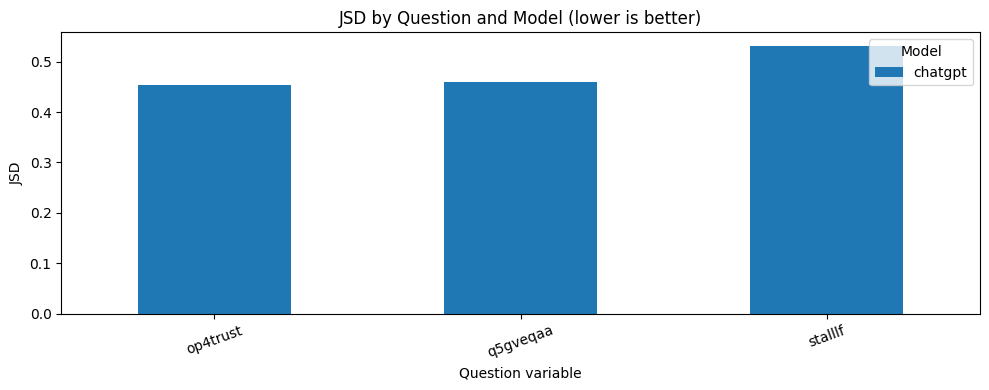


Valid answer rate:
model         chatgpt
question_var         
op4trust          1.0
q5gveqaa          1.0
stalllf           1.0


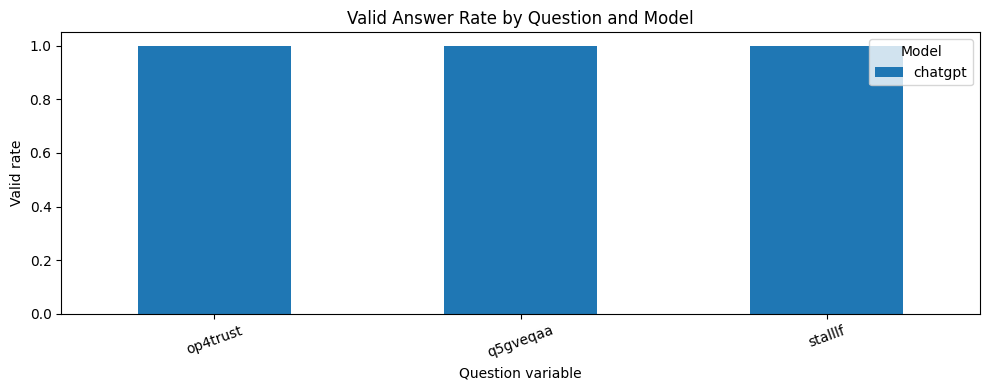


Distribution comparison — op4trust:
    real  chatgpt
1  0.027     0.12
2  0.499     0.88
3  0.412     0.00
4  0.062     0.00


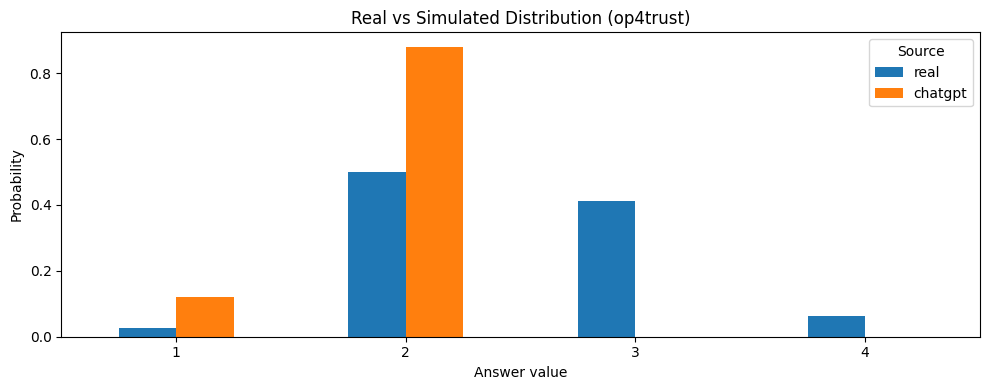

In [15]:
if 'metrics_df' not in globals() or metrics_df.empty:
    raise ValueError("metrics_df is empty — run model cells first.")
if not results_by_model:
    raise ValueError("results_by_model is empty — run model cells first.")

model_order = [m for m in ['gemini', 'chatgpt', 'claude', 'llama'] if m in metrics_df['model'].unique()]
if not model_order:
    raise ValueError("No model results in metrics_df.")

plot_df = metrics_df.copy()
plot_df['jsd'] = pd.to_numeric(plot_df['jsd'], errors='coerce')
plot_df['valid_rate'] = plot_df['valid_answers'] / plot_df['total_personas']

# 1) JSD by question and model
jsd_pivot = plot_df.pivot(index='question_var', columns='model', values='jsd').reindex(columns=model_order)
print("JSD (lower = better):")
print(jsd_pivot.round(4))
ax = jsd_pivot.plot(kind='bar', figsize=(10, 4), rot=20)
ax.set_title('JSD by Question and Model (lower is better)')
ax.set_xlabel('Question variable')
ax.set_ylabel('JSD')
ax.legend(title='Model')
plt.tight_layout(); plt.show()

# 2) Valid answer rate
valid_pivot = plot_df.pivot(index='question_var', columns='model', values='valid_rate').reindex(columns=model_order)
print("\nValid answer rate:")
print(valid_pivot.round(3))
ax = valid_pivot.plot(kind='bar', figsize=(10, 4), rot=20)
ax.set_title('Valid Answer Rate by Question and Model')
ax.set_xlabel('Question variable')
ax.set_ylabel('Valid rate')
ax.set_ylim(0, 1.05)
ax.legend(title='Model')
plt.tight_layout(); plt.show()

# 3) Distribution comparison for one question
viz_var = list(question_bank.keys())[0]   # change as needed
all_values = list(range(question_bank[viz_var]['scale_min'], question_bank[viz_var]['scale_max'] + 1))
dist_data = {
    'real': df[viz_var].dropna().astype(int)
        .value_counts(normalize=True).sort_index()
        .reindex(all_values, fill_value=0)
}
for m in model_order:
    if m in results_by_model and viz_var in results_by_model[m].columns:
        dist_data[m] = (
            results_by_model[m][viz_var].dropna().astype(int)
            .value_counts(normalize=True).sort_index()
            .reindex(all_values, fill_value=0)
        )

dist_df = pd.DataFrame(dist_data, index=all_values)
print(f"\nDistribution comparison — {viz_var}:")
print(dist_df.round(3))
ax = dist_df.plot(kind='bar', figsize=(10, 4), rot=0)
ax.set_title(f'Real vs Simulated Distribution ({viz_var})')
ax.set_xlabel('Answer value')
ax.set_ylabel('Probability')
ax.legend(title='Source')
plt.tight_layout(); plt.show()